# PROJECT OVERVIEW

**Project Summary**

This final project aims to conduct an in-depth analysis of e-commerce customer behavior using a comprehensive dataset containing 17,049 transaction records from 5,000 unique customers across the cities during the period of January 2023 to March 2024. The analysis will focus on understanding customer purchasing patterns, identifying key revenue drivers, segmenting customers based on their behavior, and providing actionable insights for business growth and customer retention strategies.


**Business Context**

Revenue Optimization: Identifying high-value customers and products
Customer Retention: Understanding factors that drive repeat purchases
Marketing Effectiveness: Targeting the right customers with appropriate strategies
Operational Efficiency: Optimizing inventory, delivery, and payment systems
Customer Experience: Improving satisfaction through data-driven decisions

#Background

Understanding customer behavior in this dynamic environment is essential for businesses to remain competitive and profitable.
Key Industry Trends:
- Increasing mobile commerce adoption
- Growing preference for digital payment methods
- Rising customer expectations for fast delivery
- Importance of personalized shopping experiences
- Multi-channel customer engagement


1. Customer Acquisition vs. Retention: Balancing the cost of acquiring new customers with retaining existing ones
2. Revenue Volatility: Managing seasonal fluctuations and unpredictable purchasing patterns
3. Customer Segmentation: Identifying and targeting different customer groups effectively
4. Operational Costs: Optimizing delivery times, inventory management, and payment processing
5. Customer Satisfaction: Maintaining high ratings while managing diverse customer expectations


**Data Driven decision making**
- Understand customer preferences and behavior patterns
- Optimize product catalog and pricing strategies
- Improve customer lifetime value (CLV)
- Enhance marketing campaign effectiveness
- Reduce cart abandonment and increase conversion rates

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Bimbing Bootcamp/FINAL PROJECT/ecommerce_customer_behavior_dataset_v2.csv")

In [3]:
df.head(10)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
5,ORD_000003-1,CUST_00003,2023-02-27,42,Male,Konya,Toys,198.28,2,0.00,396.56,Credit Card,Tablet,10,9,False,6,2
6,ORD_000003-2,CUST_00003,2024-01-03,42,Male,Konya,Home & Garden,526.85,5,0.00,2634.25,Digital Wallet,Desktop,11,8,True,6,5
7,ORD_000004-1,CUST_00004,2024-02-13,53,Male,Izmir,Fashion,96.20,5,97.78,383.22,Credit Card,Desktop,16,15,False,4,5
8,ORD_000005-1,CUST_00005,2023-03-16,32,Male,Ankara,Home & Garden,533.67,3,0.00,1601.01,Bank Transfer,Mobile,12,8,False,5,5
9,ORD_000005-2,CUST_00005,2023-06-12,32,Male,Ankara,Toys,73.06,4,0.00,292.24,Credit Card,Mobile,13,12,True,7,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [5]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week_of_Year'] = df['Date'].dt.isocalendar().week

df['Is_Returning_Customer_Int'] = df['Is_Returning_Customer'].astype(int)

print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days} days")

Date Range: 2023-01-01 to 2024-03-25
Total Days: 449 days


In [7]:
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Data_Type': df.dtypes.values,
    'Sample_Value': [df[col].iloc[0] for col in df.columns]
})

display(unique_counts)

,Column,Unique_Values,Data_Type,Sample_Value
0,Order_ID,17049,object,ORD_000001-1
1,Customer_ID,5000,object,CUST_00001
2,Date,450,datetime64[ns],2023-05-29 00:00:00
3,Age,57,int64,40
4,Gender,3,object,Male
5,City,10,object,Ankara
6,Product_Category,8,object,Books
7,Unit_Price,14711,float64,29.18
8,Quantity,5,int64,1
9,Discount_Amount,5526,float64,0.0


In [8]:
print(f"Total Transactions: {df.shape[0]:,}")
print(f"Unique Customers: {df['Customer_ID'].nunique():,}")
print(f"Unique Orders: {df['Order_ID'].nunique():,}")
print(f"Cities Covered: {df['City'].nunique()}")
print(f"Product Categories: {df['Product_Category'].nunique()}")
print(f"Payment Methods: {df['Payment_Method'].nunique()}")
print(f"Device Types: {df['Device_Type'].nunique()}")
print(f"\nTotal Revenue: ${df['Total_Amount'].sum():,.2f}")
print(f"Average Order Value: ${df['Total_Amount'].mean():,.2f}")
print(f"Average Revenue per Customer: ${df.groupby('Customer_ID')['Total_Amount'].sum().mean():,.2f}")

Total Transactions: 17,049
Unique Customers: 5,000
Unique Orders: 17,049
Cities Covered: 10
Product Categories: 8
Payment Methods: 5
Device Types: 3

Total Revenue: $21,779,052.59
Average Order Value: $1,277.44
Average Revenue per Customer: $4,355.81


In [9]:
missing_values = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)


if len(missing_values) == 0:
    print("No missing values found! Dataset is 100% complete.")
else:
    display(missing_values)

No missing values found! Dataset is 100% complete.


In [10]:
duplicates = df.duplicated().sum()
duplicate_order_ids = df['Order_ID'].duplicated().sum()

print(f"Duplicate Rows (complete): {duplicates}")
print(f"Duplicate Order IDs: {duplicate_order_ids}")

if duplicates == 0:
    print("No duplicate rows found!")
else:
    print(f"Found {duplicates} duplicate rows")

Duplicate Rows (complete): 0
Duplicate Order IDs: 0
No duplicate rows found!


In [11]:
negative_checks = {
    'Negative Age': (df['Age'] < 0).sum(),
    'Negative Unit Price': (df['Unit_Price'] < 0).sum(),
    'Negative Quantity': (df['Quantity'] < 0).sum(),
    'Negative Total Amount': (df['Total_Amount'] < 0).sum(),
    'Negative Discount': (df['Discount_Amount'] < 0).sum(),
    'Negative Delivery Days': (df['Delivery_Time_Days'] < 0).sum(),
}

print("\nNegative Values Check:")
for check, count in negative_checks.items():
    status = "Correct" if count == 0 else "Incorrect"
    print(f"  {status} {check}: {count}")

# Check age range
print(f"\nAge Range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"   Valid age range (18-100): {((df['Age'] >= 18) & (df['Age'] <= 100)).sum()} records")

# Check rating range
print(f"\nRating Range: {df['Customer_Rating'].min()} - {df['Customer_Rating'].max()} stars")
print(f"   Valid ratings (1-5): {((df['Customer_Rating'] >= 1) & (df['Customer_Rating'] <= 5)).sum()} records")

# Check business logic
df['Calculated_Amount'] = (df['Unit_Price'] * df['Quantity']) - df['Discount_Amount']
df['Amount_Difference'] = abs(df['Total_Amount'] - df['Calculated_Amount'])
amount_mismatches = (df['Amount_Difference'] > 0.01).sum()

print(f"\nTotal Amount Calculation Check:")
print(f"Mismatches (>€0.01 difference): {amount_mismatches}")
if amount_mismatches > 0:
    print(f"{amount_mismatches} records have calculation discrepancies")
else:
    print(f"All amount calculations are correct!")


Negative Values Check:
  Correct Negative Age: 0
  Correct Negative Unit Price: 0
  Correct Negative Quantity: 0
  Correct Negative Total Amount: 0
  Correct Negative Discount: 0
  Correct Negative Delivery Days: 0

Age Range: 18 - 75 years
   Valid age range (18-100): 17049 records

Rating Range: 1 - 5 stars
   Valid ratings (1-5): 17049 records

Total Amount Calculation Check:
Mismatches (>€0.01 difference): 0
All amount calculations are correct!


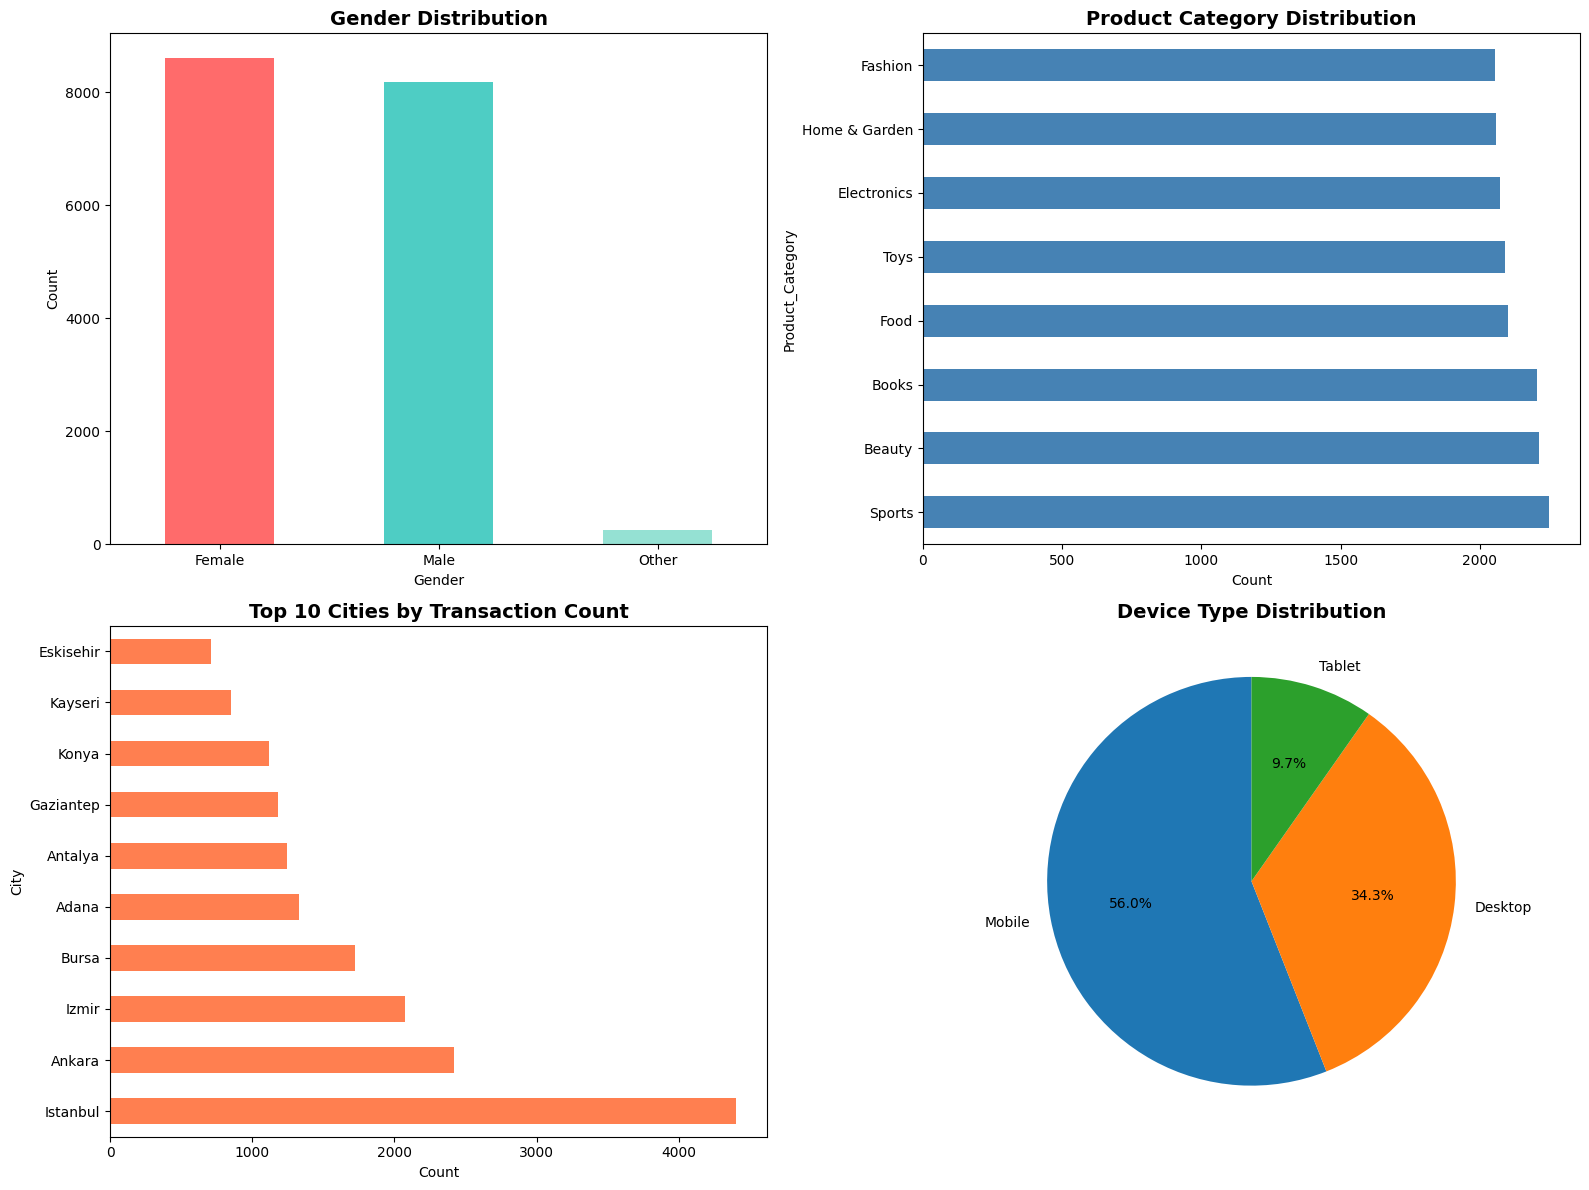


Distribution Summary:
• Most common gender: Female
• Most sold category: Sports
• Largest market: Istanbul
• Primary device: Mobile


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[0,0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

df['Product_Category'].value_counts().plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Product Category Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Count')

df['City'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Top 10 Cities by Transaction Count', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Count')

df['Device_Type'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Device Type Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nDistribution Summary:")
print(f"• Most common gender: {df['Gender'].value_counts().index[0]}")
print(f"• Most sold category: {df['Product_Category'].value_counts().index[0]}")
print(f"• Largest market: {df['City'].value_counts().index[0]}")
print(f"• Primary device: {df['Device_Type'].value_counts().index[0]}")

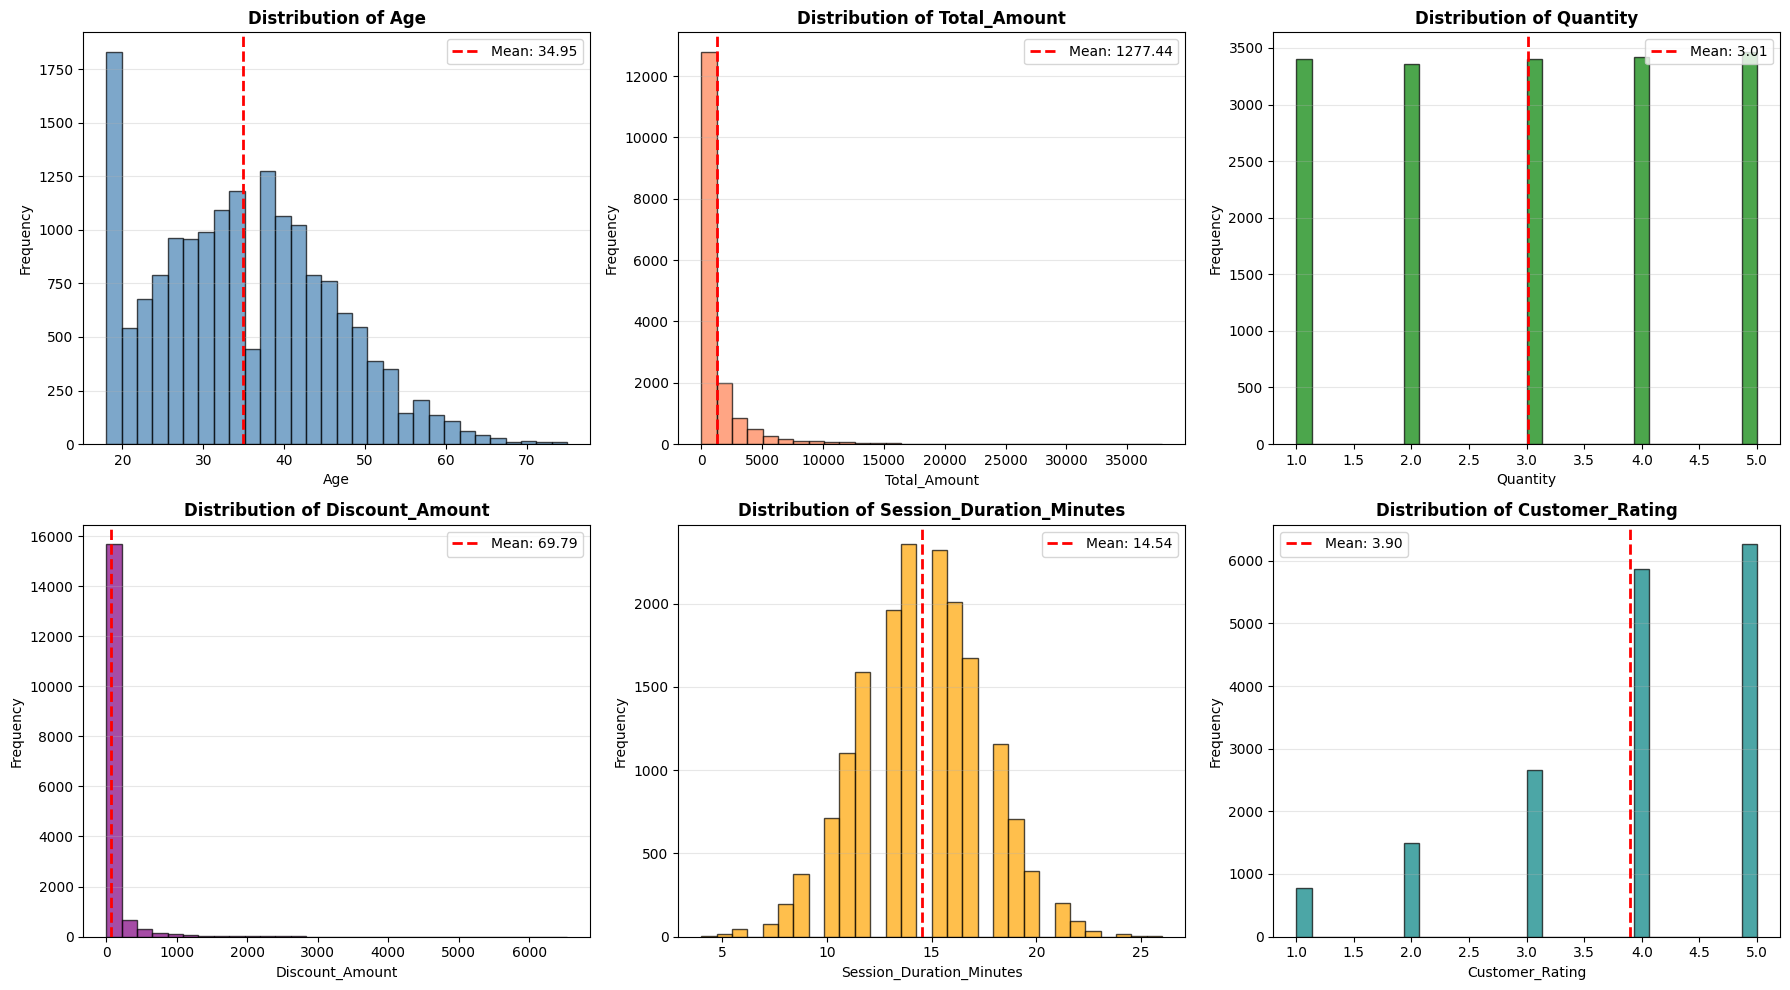

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

numerical_vars = ['Age', 'Total_Amount', 'Quantity', 'Discount_Amount', 'Session_Duration_Minutes', 'Customer_Rating']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'teal']

for idx, (var, color) in enumerate(zip(numerical_vars, colors)):
    axes[idx].hist(df[var], bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[var].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[var].mean():.2f}')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

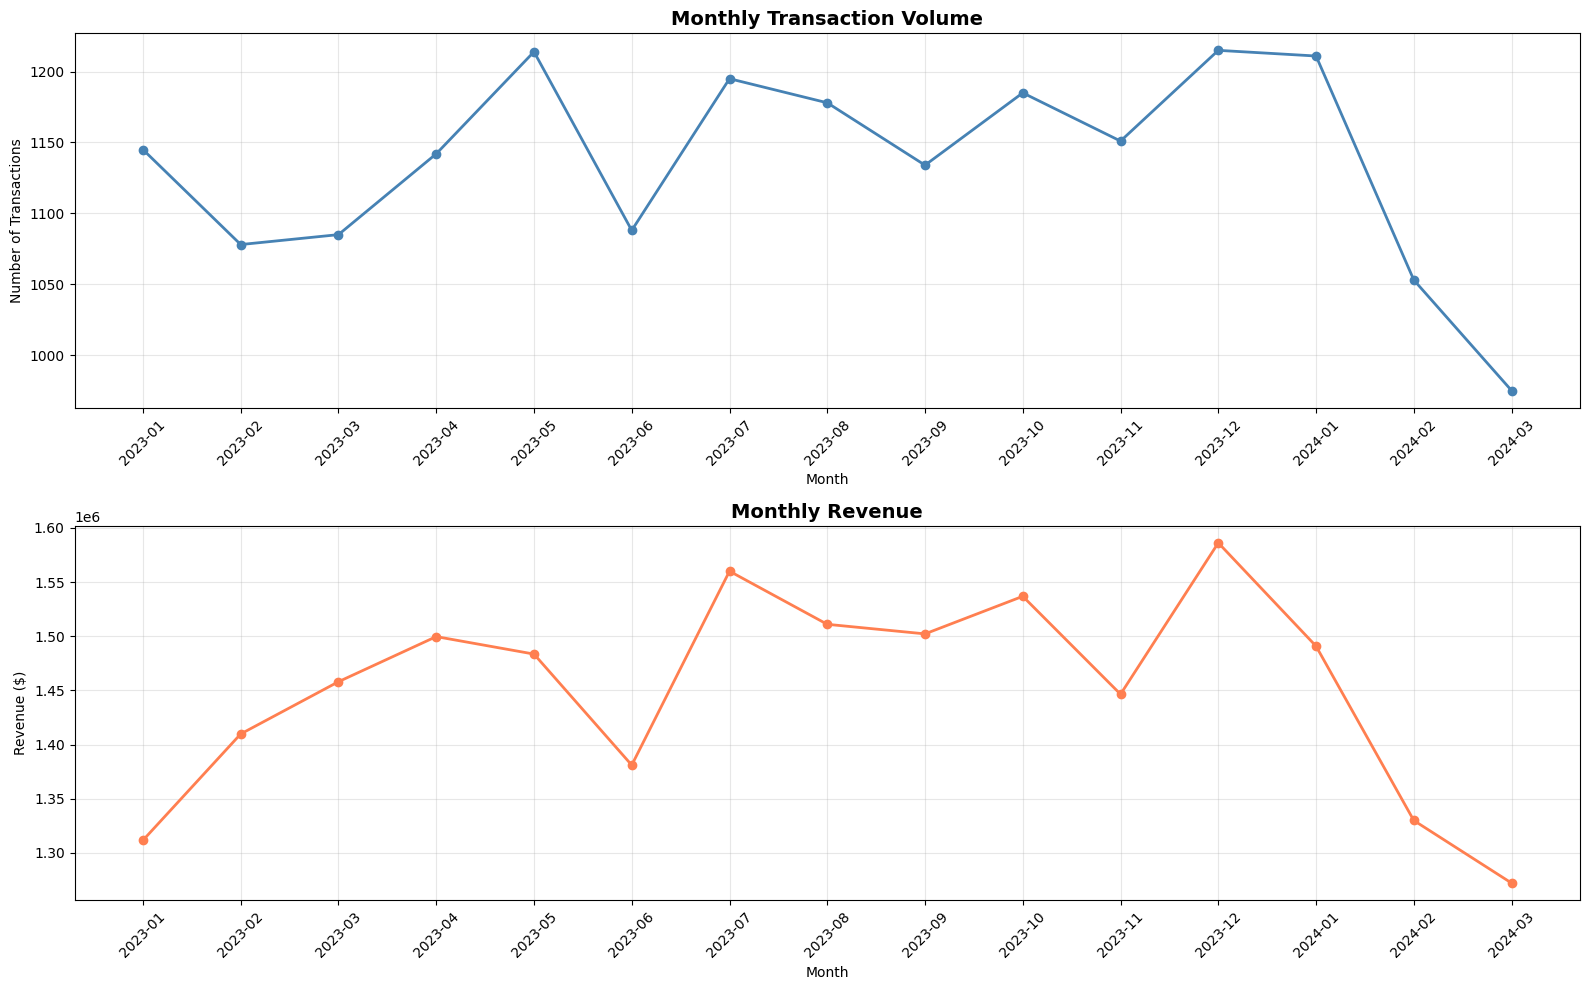


Temporal Insights:
• Best month (revenue): 2023-12
• Best month (volume): 2023-12
• Total revenue: $21,779,052.59


In [14]:
monthly_stats = df.groupby(['Year', 'Month']).agg({
    'Order_ID': 'count',
    'Total_Amount': 'sum',
    'Customer_ID': 'nunique'
}).reset_index()

monthly_stats['YearMonth'] = monthly_stats['Year'].astype(str) + '-' + monthly_stats['Month'].astype(str).str.zfill(2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

ax1.plot(monthly_stats['YearMonth'], monthly_stats['Order_ID'], marker='o', linewidth=2, markersize=6, color='steelblue')
ax1.set_title('Monthly Transaction Volume', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Transactions')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3)

ax2.plot(monthly_stats['YearMonth'], monthly_stats['Total_Amount'], marker='o', linewidth=2, markersize=6, color='coral')
ax2.set_title('Monthly Revenue', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTemporal Insights:")
print(f"• Best month (revenue): {monthly_stats.loc[monthly_stats['Total_Amount'].idxmax(), 'YearMonth']}")
print(f"• Best month (volume): {monthly_stats.loc[monthly_stats['Order_ID'].idxmax(), 'YearMonth']}")
print(f"• Total revenue: ${monthly_stats['Total_Amount'].sum():,.2f}")

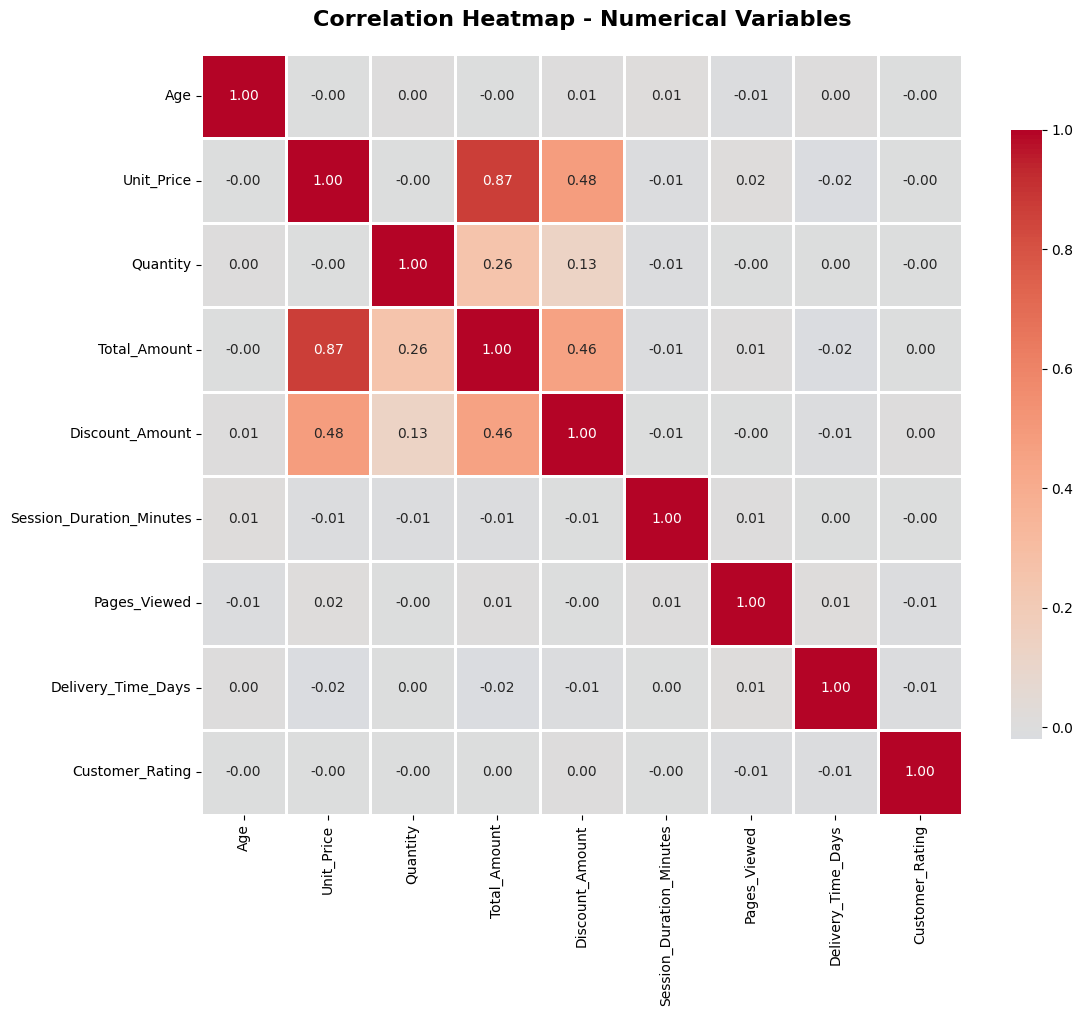


Key Correlations with Total_Amount:
  • Unit_Price                    :  0.866
  • Discount_Amount               :  0.456
  • Quantity                      :  0.257
  • Pages_Viewed                  :  0.009
  • Customer_Rating               :  0.001
  • Age                           : -0.004
  • Session_Duration_Minutes      : -0.009
  • Delivery_Time_Days            : -0.016


In [15]:
correlation_vars = ['Age', 'Unit_Price', 'Quantity', 'Total_Amount', 'Discount_Amount',
                    'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']

correlation_matrix = df[correlation_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey Correlations with Total_Amount:")
amount_corr = correlation_matrix['Total_Amount'].sort_values(ascending=False)
for var, corr in amount_corr.items():
    if var != 'Total_Amount':
        print(f"  • {var:30s}: {corr:6.3f}")

In [16]:
print("Creating new features...")

df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56+'])

df['Price_Category'] = pd.cut(df['Unit_Price'], bins=[0, 100, 300, 600, 10000],
                              labels=['Low', 'Medium', 'High', 'Premium'])

df['Order_Value_Category'] = pd.cut(df['Total_Amount'], bins=[0, 100, 500, 1000, 10000],
                                     labels=['Small', 'Medium', 'Large', 'Very Large'])

df['Discount_Percentage'] = np.where(df['Unit_Price'] * df['Quantity'] > 0,
                                     (df['Discount_Amount'] / (df['Unit_Price'] * df['Quantity']) * 100), 0)
df['Has_Discount'] = (df['Discount_Amount'] > 0).astype(int)

df['Delivery_Speed'] = pd.cut(df['Delivery_Time_Days'], bins=[0, 3, 6, 10, 30],
                               labels=['Fast', 'Normal', 'Slow', 'Very Slow'])

df['Engagement_Score'] = (df['Session_Duration_Minutes'] * 0.5) + (df['Pages_Viewed'] * 0.5)
df['Engagement_Level'] = pd.cut(df['Engagement_Score'], bins=[0, 10, 15, 20, 100],
                                labels=['Low', 'Medium', 'High', 'Very High'])

df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)
df['Season'] = df['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Fall', 10: 'Fall', 11: 'Fall'})

print("Feature engineering completed!")
print(f"\nTotal features now: {df.shape[1]}")

Creating new features...
Feature engineering completed!

Total features now: 37


In [17]:
from datetime import timedelta

analysis_date = df['Date'].max() + timedelta(days=1)
print(f"Analysis Date: {analysis_date.date()}")

rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (analysis_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Amount': 'sum'
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print(f"\nRFM metrics calculated for {len(rfm):,} customers")
print(f"\nRFM Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

def create_rfm_score_robust(series, ascending=True):
    """
    RFM score (1-5) using ranking
    - For Frequency & Monetary: ascending=True (higher value = higher score)
    - For Recency: ascending=False (lower days = higher score, more recent is better)
    """
    if ascending:
        score = pd.qcut(series.rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
    else:
        score = pd.qcut(series.rank(method='first'), q=5, labels=[5, 4, 3, 2, 1])
    return score


rfm['R_Score'] = create_rfm_score_robust(rfm['Recency'], ascending=False).astype(int)
rfm['F_Score'] = create_rfm_score_robust(rfm['Frequency'], ascending=True).astype(int)
rfm['M_Score'] = create_rfm_score_robust(rfm['Monetary'], ascending=True).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Sum'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(f"\nScore Distribution:")
print(rfm[['R_Score', 'F_Score', 'M_Score']].describe())

def assign_segment(row):
    """
    Assign customer segment based on RFM scores

    Segmentation Logic:
    - Champions: R≥4, F≥4, M≥4 (Best customers)
    - Loyal Customers: F≥4, M≥3 (Buy often, spend well)
    - Potential Loyalists: R≥4, F≥2, M≥2 (Recent, promising)
    - Recent Customers: R≥4, F≤2 (New customers)
    - Promising: R≥3, M≥3 (Recent with good spending)
    - Needs Attention: R≥3, F≥3 (Declining)
    - About to Sleep: R≤2, F≥2 (Haven't purchased recently)
    - At Risk: R≤2, F≥4, M≥4 (Used to be good)
    - Cannot Lose Them: R≤1, F≥4, M≥4 (Valuable but inactive)
    - Hibernating: R≤2, F≤2, M≤2 (Low activity)
    - Lost: R≤2 (Haven't returned)
    - Others: Don't fit above categories
    """
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and m >= 3:
        return 'Promising'
    elif r >= 3 and f >= 3:
        return 'Needs Attention'
    elif r <= 2 and f >= 2:
        return 'About to Sleep'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 1 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    elif r <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(f"\nTotal unique segments: {rfm['Segment'].nunique()}")

print("SEGMENT DISTRIBUTION")

segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)
for segment, count in segment_counts.items():
    percentage = (count / len(rfm) * 100)
    print(f"  {segment:25s}: {count:5,} customers ({percentage:5.1f}%)")

print(f"\nSample RFM Data:")
display(rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary',
             'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']].head(10))

Analysis Date: 2024-03-26

RFM metrics calculated for 5,000 customers

RFM Statistics:
       Recency  Frequency  Monetary
count  5000.00    5000.00   5000.00
mean    125.72       3.41   4355.81
std     108.05       2.18   5274.55
min       1.00       1.00     14.28
25%      39.00       2.00    889.41
50%      94.00       3.00   2493.93
75%     185.00       5.00   5796.30
max     450.00      10.00  50628.15

Score Distribution:
           R_Score      F_Score      M_Score
count  5000.000000  5000.000000  5000.000000
mean      3.000000     3.000000     3.000000
std       1.414355     1.414355     1.414355
min       1.000000     1.000000     1.000000
25%       2.000000     2.000000     2.000000
50%       3.000000     3.000000     3.000000
75%       4.000000     4.000000     4.000000
max       5.000000     5.000000     5.000000

Total unique segments: 10
SEGMENT DISTRIBUTION
  About to Sleep           :   985 customers ( 19.7%)
  Loyal Customers          :   920 customers ( 18.4%)
  Champ

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST_00001,112,3,2199.63,3,3,3,333,Promising
1,CUST_00002,284,2,809.90,1,1,2,112,Hibernating
2,CUST_00003,83,2,3030.81,3,1,3,313,Promising
3,CUST_00004,42,1,383.22,4,1,1,411,Recent Customers
4,CUST_00005,279,3,2422.73,1,3,3,133,About to Sleep
5,CUST_00006,212,3,1245.83,2,3,2,232,About to Sleep
6,CUST_00007,81,1,1331.55,3,1,2,312,Others
7,CUST_00008,169,3,5602.29,2,3,4,234,About to Sleep
8,CUST_00009,39,1,470.86,4,1,1,411,Recent Customers
9,CUST_00010,22,3,1421.16,5,3,2,532,Potential Loyalists


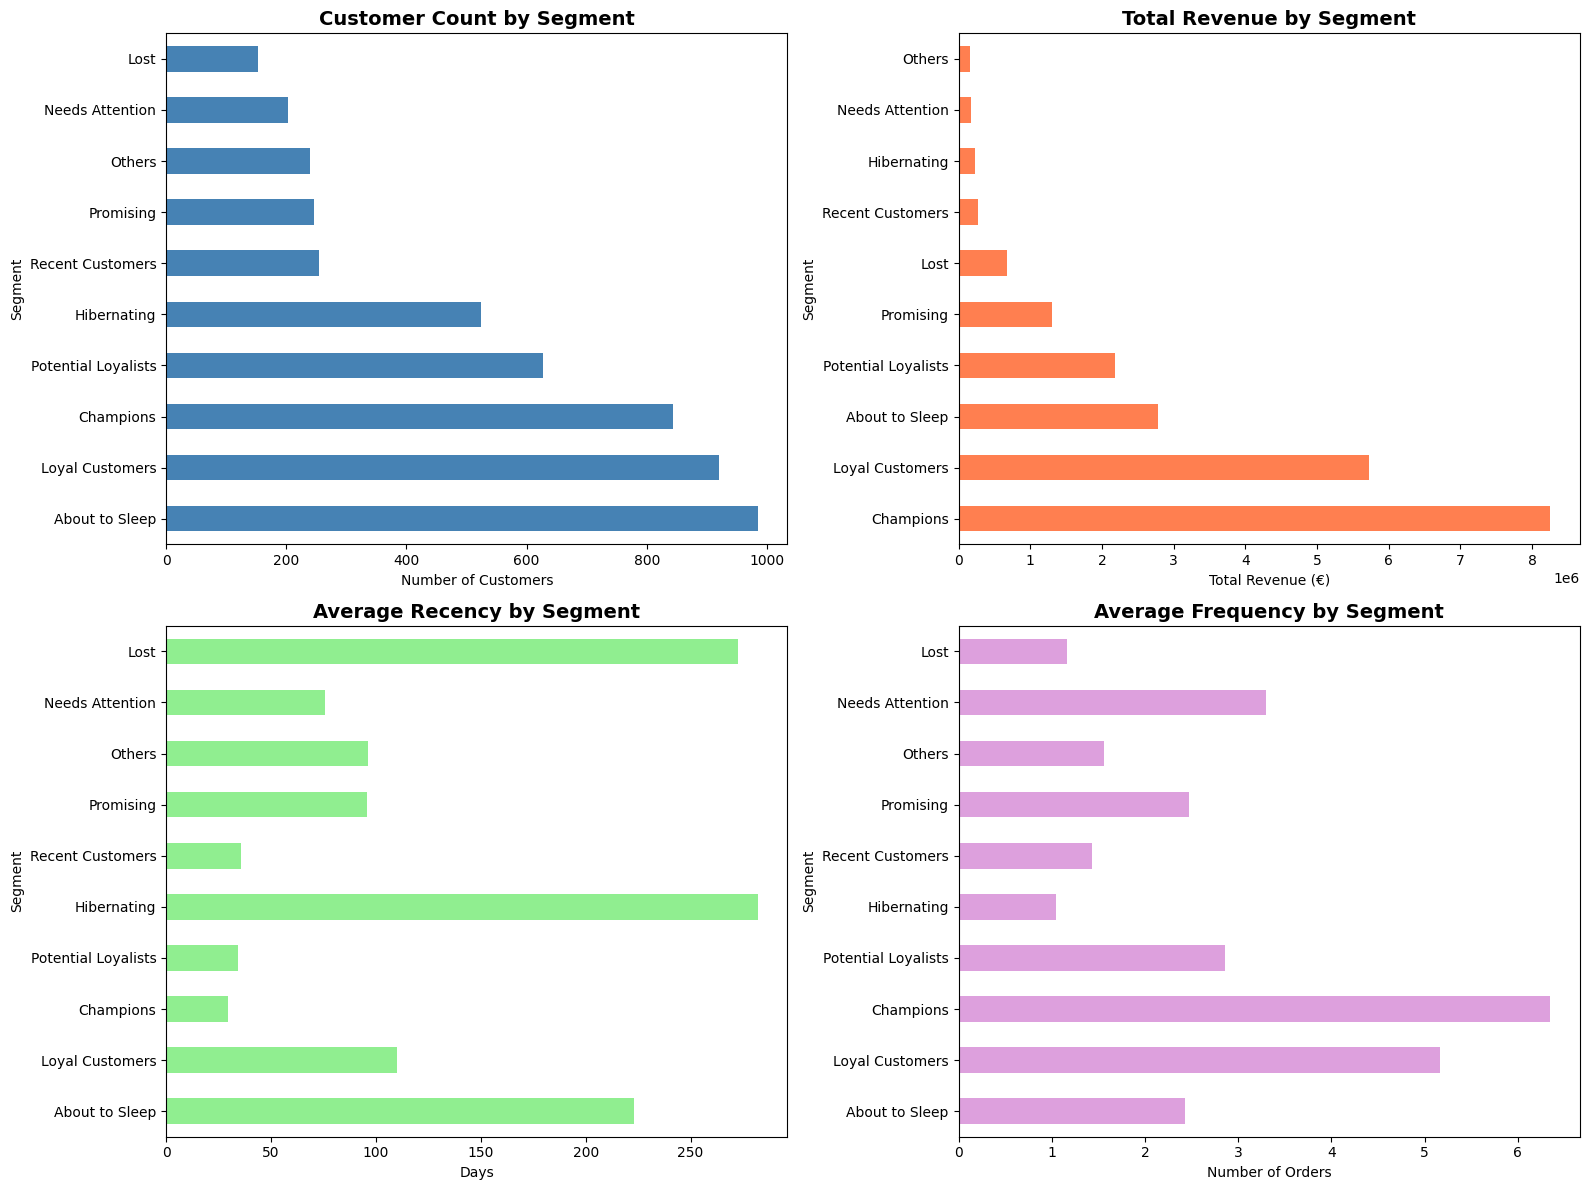

,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
About to Sleep,985,223.24,2.43,2824.39
Loyal Customers,920,110.06,5.17,6224.91
Champions,844,29.52,6.35,9781.56
Potential Loyalists,628,34.17,2.86,3486.00
Hibernating,525,282.10,1.05,446.61
Recent Customers,255,35.72,1.43,1065.96
Promising,247,95.55,2.47,5291.15
Others,240,96.23,1.56,664.53
Needs Attention,203,75.99,3.30,880.25


In [18]:
segment_summary = rfm.groupby('Segment').agg({
    'Customer_ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_summary.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
segment_summary = segment_summary.sort_values('Count', ascending=False)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

segment_summary['Count'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Customers')

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Total Revenue by Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Revenue (€)')

segment_summary['Avg_Recency'].plot(kind='barh', ax=ax3, color='lightgreen')
ax3.set_title('Average Recency by Segment', fontsize=14, fontweight='bold')
ax3.set_xlabel('Days')

segment_summary['Avg_Frequency'].plot(kind='barh', ax=ax4, color='plum')
ax4.set_title('Average Frequency by Segment', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

display(segment_summary)

In [19]:
print("HYPOTHESIS TESTING")

returning = df[df['Is_Returning_Customer'] == True]['Total_Amount']
new = df[df['Is_Returning_Customer'] == False]['Total_Amount']
t_stat, p_value = stats.ttest_ind(returning, new)

print("\nTest 1: AOV - Returning vs New Customers")
print(f"  Returning Mean: ${returning.mean():.2f}")
print(f"  New Mean: ${new.mean():.2f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'}")

male = df[df['Gender'] == 'Male']['Total_Amount']
female = df[df['Gender'] == 'Female']['Total_Amount']
t_stat, p_value = stats.ttest_ind(male, female)

print("\nTest 2: AOV - Male vs Female")
print(f"  Male Mean: ${male.mean():.2f}")
print(f"  Female Mean: ${female.mean():.2f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'}")

mobile = df[df['Device_Type'] == 'Mobile']['Total_Amount']
desktop = df[df['Device_Type'] == 'Desktop']['Total_Amount']
t_stat, p_value = stats.ttest_ind(mobile, desktop)

print("\nTest 3: AOV - Mobile vs Desktop")
print(f"  Mobile Mean: ${mobile.mean():.2f}")
print(f"  Desktop Mean: ${desktop.mean():.2f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'}")

HYPOTHESIS TESTING

Test 1: AOV - Returning vs New Customers
  Returning Mean: $1276.06
  New Mean: $1287.73
  P-value: 0.835045
  Result: No significant difference

Test 2: AOV - Male vs Female
  Male Mean: $1265.07
  Female Mean: $1281.55
  P-value: 0.648362
  Result: No significant difference

Test 3: AOV - Mobile vs Desktop
  Mobile Mean: $1260.47
  Desktop Mean: $1310.77
  P-value: 0.202080
  Result: No significant difference


In [20]:
import os

output_dir = 'powerbi_data'
os.makedirs(output_dir, exist_ok=True)

powerbi_main = df[['Order_ID', 'Customer_ID', 'Date', 'Year', 'Month', 'Month_Name', 'Quarter',
                   'Day_of_Week', 'Week_of_Year', 'Is_Weekend', 'Season', 'Age', 'Age_Group',
                   'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Price_Category',
                   'Discount_Amount', 'Discount_Percentage', 'Has_Discount', 'Total_Amount',
                   'Order_Value_Category', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes',
                   'Pages_Viewed', 'Engagement_Score', 'Engagement_Level', 'Is_Returning_Customer',
                   'Delivery_Time_Days', 'Delivery_Speed', 'Customer_Rating']].copy()

powerbi_main.to_csv(f'{output_dir}/01_transactions_fact.csv', index=False, encoding='utf-8-sig')

customer_dim = df.groupby('Customer_ID').agg({
    'Age': 'first', 'Age_Group': 'first', 'Gender': 'first', 'City': 'first',
    'Date': 'min', 'Order_ID': 'count', 'Total_Amount': 'sum', 'Customer_Rating': 'mean'
}).reset_index()

customer_dim.columns = ['Customer_ID', 'Age', 'Age_Group', 'Gender', 'City',
                       'First_Purchase_Date', 'Total_Orders', 'Total_Spending', 'Avg_Rating']

customer_dim = customer_dim.merge(rfm[['Customer_ID', 'Recency', 'Frequency', 'Monetary',
                                       'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']],
                                 on='Customer_ID', how='left')

customer_dim['Customer_Value_Tier'] = pd.qcut(customer_dim['Total_Spending'], q=4,
                                              labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

customer_dim.to_csv(f'{output_dir}/02_customer_dimension.csv', index=False, encoding='utf-8-sig')

date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
date_dim = pd.DataFrame({
    'Date': date_range, 'Year': date_range.year, 'Quarter': date_range.quarter,
    'Month': date_range.month, 'Month_Name': date_range.month_name(),
    'Week_of_Year': date_range.isocalendar().week, 'Day_of_Month': date_range.day,
    'Day_of_Week': date_range.dayofweek + 1, 'Day_Name': date_range.day_name(),
    'Is_Weekend': date_range.dayofweek.isin([5, 6]).astype(int)
})

date_dim.to_csv(f'{output_dir}/03_date_dimension.csv', index=False, encoding='utf-8-sig')

monthly_summary = df.groupby(['Year', 'Month']).agg({
    'Order_ID': 'count', 'Customer_ID': 'nunique', 'Total_Amount': ['sum', 'mean'],
    'Quantity': 'sum', 'Customer_Rating': 'mean', 'Discount_Amount': 'sum'
}).round(2)
monthly_summary.columns = ['Transactions', 'Customers', 'Revenue', 'AOV', 'Quantity', 'Rating', 'Discounts']
monthly_summary.reset_index().to_csv(f'{output_dir}/04_monthly_summary.csv', index=False, encoding='utf-8-sig')

category_summary = df.groupby('Product_Category').agg({
    'Order_ID': 'count', 'Total_Amount': ['sum', 'mean'], 'Quantity': 'sum',
    'Customer_Rating': 'mean', 'Customer_ID': 'nunique'
}).round(2)
category_summary.columns = ['Transactions', 'Revenue', 'AOV', 'Quantity', 'Rating', 'Customers']
category_summary.reset_index().to_csv(f'{output_dir}/05_category_summary.csv', index=False, encoding='utf-8-sig')

city_summary = df.groupby('City').agg({
    'Order_ID': 'count', 'Total_Amount': ['sum', 'mean'], 'Customer_ID': 'nunique',
    'Customer_Rating': 'mean', 'Delivery_Time_Days': 'mean'
}).round(2)
city_summary.columns = ['Transactions', 'Revenue', 'AOV', 'Customers', 'Rating', 'Avg_Delivery']
city_summary.reset_index().to_csv(f'{output_dir}/06_city_summary.csv', index=False, encoding='utf-8-sig')

rfm.to_csv(f'{output_dir}/07_rfm_segments.csv', index=False, encoding='utf-8-sig')

print("ALL DATA EXPORTED TO 'powerbi_data' FOLDER!")
print("\nFiles ready for Power BI:")
print("  1. 01_transactions_fact.csv")
print("  2. 02_customer_dimension.csv")
print("  3. 03_date_dimension.csv")
print("  4. 04_monthly_summary.csv")
print("  5. 05_category_summary.csv")
print("  6. 06_city_summary.csv")
print("  7. 07_rfm_segments.csv")

ALL DATA EXPORTED TO 'powerbi_data' FOLDER!

Files ready for Power BI:
  1. 01_transactions_fact.csv
  2. 02_customer_dimension.csv
  3. 03_date_dimension.csv
  4. 04_monthly_summary.csv
  5. 05_category_summary.csv
  6. 06_city_summary.csv
  7. 07_rfm_segments.csv
